## Setup

In [6]:
from pathlib import Path
import os
import re

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image
from sklearn.model_selection import train_test_split

from breast_cancer.data import (
    augment_images,
    cbisd_extract_pixels,
    cbisd_import_description,
)

In [7]:
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

with open("../configs/augment.yml") as f:
    augment_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [8]:
IMG_SIZE = default_cfg["image_resize"]
N_AUGMENT = augment_cfg["n_augment"]

In [9]:
dir_raw = Path(default_cfg["dirs"]["raw_images"])
dir_processed = Path(default_cfg["dirs"]["processed_images"])
dir_augmented = Path(default_cfg["dirs"]["augmented_images"])
dir_data_split = Path(default_cfg["dirs"]["data_split"])

dir_raw.mkdir(exist_ok=True)
dir_processed.mkdir(exist_ok=True)
dir_augmented.mkdir(exist_ok=True)
dir_data_split.mkdir(exist_ok=True)

In [10]:
def visualize_augmentation(pipeline, images, max_size=512, num_examples=4):
    """Show multiple augmentation results.

    This is a modification from albumetnationsx documentation.
        https://albumentations.ai/docs/2-core-concepts/transforms/#validation-and-debugging
    """
    resizing = A.Resize(max_size, max_size)

    fig, axes = plt.subplots(len(images), num_examples + 1, figsize=(12, 8))

    for i, image in enumerate(images):
        # Original
        image = resizing(image=image)["image"]
        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        # Augmented examples
        for j in range(num_examples):
            augmented = pipeline(image=image)["image"]
            axes[i, j + 1].imshow(augmented)
            axes[i, j + 1].set_title(f"Augmented {j + 1}")
            axes[i, j + 1].axis("off")

    plt.tight_layout()
    plt.show()

## Extract Images from Mammogram Datasets

#### Get Data Descriptions

In [4]:
# Extract metadata from csv files
cbisd = cbisd_import_description(default_cfg["cbisddsm"]["description_files"])
cbisd.head()

,source,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast_density,image paths,image labels
0,calc_case_description_test_set.csv,P_00038,2.0,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,NaN,NaN,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,NaN,Calc-Test_P_00038_LEFT_CC_1,benign
1,calc_case_description_test_set.csv,P_00038,2.0,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,NaN,NaN,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,NaN,Calc-Test_P_00038_LEFT_MLO_1,benign
2,calc_case_description_test_set.csv,P_00038,2.0,RIGHT,CC,1,calcification,VASCULAR,NaN,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,NaN,Calc-Test_P_00038_RIGHT_CC_1,benign
3,calc_case_description_test_set.csv,P_00038,2.0,RIGHT,CC,2,calcification,VASCULAR,NaN,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....,NaN,Calc-Test_P_00038_RIGHT_CC_2,benign
4,calc_case_description_test_set.csv,P_00038,2.0,RIGHT,MLO,1,calcification,VASCULAR,NaN,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...,NaN,Calc-Test_P_00038_RIGHT_MLO_1,benign


#### Extract Images from DICOM files

In [5]:
# Get image labels (benign vs malignant) for each image path
img_labels = cbisd[["image paths", "image labels"]]
img_labels = img_labels.set_index("image paths")["image labels"]

In [6]:
img_fnames, img_pixels = cbisd_extract_pixels(default_cfg["cbisddsm"]["raw_dir"])

Reading CBIS-DDSM DICOMs: 100%|██████████| 10239/10239 [15:27<00:00, 11.04it/s]


In [7]:
# Assert data processed from DICOM files and CSV files match
assert img_labels.index.isin(img_fnames).all()

#### Save into PNGs

In [ ]:
# Make new directores for each unique image label
for lbl in img_labels.unique():
    os.makedirs(dir_processed / lbl, exist_ok=True)

# Save images into directories
for pixel, path in zip(img_pixels, img_fnames):
    target_path = os.path.join(dir_processed / img_labels[path] / f"{path}.png")
    Image.fromarray(pixel).save(target_path)

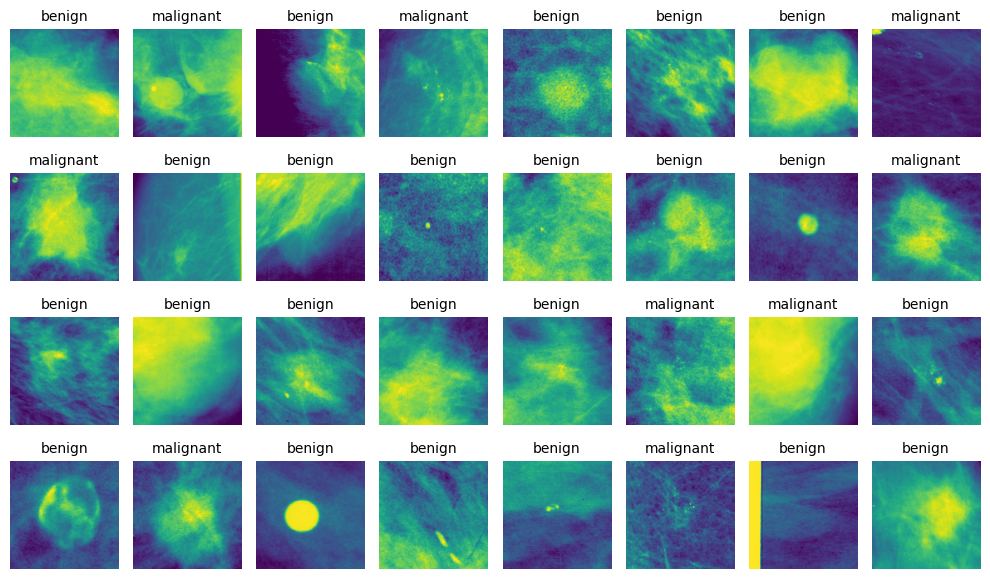

In [9]:
# Visualize sample images
img_indices = np.random.choice(len(img_pixels), size=32)

fig, axs = plt.subplots(4, 8, figsize=(10, 6))
axs = axs.flatten()
for i, img_index in enumerate(img_indices):
    axs[i].imshow(Image.fromarray(img_pixels[img_index]).resize((128, 128)))
    axs[i].set_title(img_labels.iloc[img_index], fontsize=10)
    axs[i].axis("off")
plt.tight_layout()
plt.show()

## Split Datasets

#### Prepare dataframes for splitting

In [8]:
image_paths = list(dir_raw.glob("*/*.png"))
image_paths[:5]

[]

In [63]:
# # Ensure all images from exported images are exists in official data descriptions
# x1 = set([path.stem for path in image_paths if "Test_P" in path.stem])
# x2 = set(cbisd[cbisd["source"].apply(lambda x: "test" in x)]["image paths"].tolist())
# assert x1 == x2

# x1 = set([path.stem for path in image_paths if "Training_P" in path.stem])
# x2 = set(cbisd[cbisd["source"].apply(lambda x: "train" in x)]["image paths"].tolist())
# assert x1 == x2

In [64]:
# Ensure all file names are unique
assert len(set(path.stem for path in image_paths)) == len(image_paths)

In [65]:
df = pd.DataFrame(
    [
        {
            "raw": str(path),
            "processed": dir_processed / path.name,
            "imageID": path.stem,
            "patientID": re.search(r"P_\d+", path.stem).group(0),
            "label": path.parts[-2],
        }
        for path in image_paths
    ]
)

df

,raw,processed,imageID,patientID,label
0,..\data\images\raw\benign\Calc-Test_P_00038_LE...,..\data\images\processed\Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign
1,..\data\images\raw\benign\Calc-Test_P_00038_LE...,..\data\images\processed\Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_MLO_1,P_00038,benign
2,..\data\images\raw\benign\Calc-Test_P_00038_RI...,..\data\images\processed\Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_CC_1,P_00038,benign
3,..\data\images\raw\benign\Calc-Test_P_00038_RI...,..\data\images\processed\Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_CC_2,P_00038,benign
4,..\data\images\raw\benign\Calc-Test_P_00038_RI...,..\data\images\processed\Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_MLO_1,P_00038,benign
...,...,...,...,...,...
3563,..\data\images\raw\malignant\Mass-Training_P_0...,..\data\images\processed\Mass-Training_P_02033...,Mass-Training_P_02033_RIGHT_MLO_1,P_02033,malignant
3564,..\data\images\raw\malignant\Mass-Training_P_0...,..\data\images\processed\Mass-Training_P_02079...,Mass-Training_P_02079_RIGHT_CC_1,P_02079,malignant
3565,..\data\images\raw\malignant\Mass-Training_P_0...,..\data\images\processed\Mass-Training_P_02079...,Mass-Training_P_02079_RIGHT_MLO_1,P_02079,malignant
3566,..\data\images\raw\malignant\Mass-Training_P_0...,..\data\images\processed\Mass-Training_P_02092...,Mass-Training_P_02092_LEFT_CC_1,P_02092,malignant


In [66]:
from tqdm import tqdm

for path_raw, path_processed in tqdm(
    zip(df["raw"].tolist(), df["processed"].tolist()), total=df.shape[0]
):
    img = Image.open(path_raw).resize((IMG_SIZE, IMG_SIZE)).save(path_processed)

100%|██████████| 3568/3568 [01:22<00:00, 43.04it/s]


#### Split datasets at patient level

In [67]:
train_full_size = default_cfg["split_size"]["train"] + default_cfg["split_size"]["val"]
train_part_size = default_cfg["split_size"]["train"] / train_full_size

train_full_size, train_part_size

(0.8, 0.7999999999999999)

In [68]:
# Split into full train and test data by patient ID
train_patientIDs, test_patientIDs = train_test_split(
    df["patientID"].unique(),
    train_size=train_full_size,
    random_state=default_cfg["random_seed"],
)

# Split full train into train and validation data by patient ID
train_patientIDs, val_patientIDs = train_test_split(
    train_patientIDs,
    train_size=train_part_size,
    random_state=default_cfg["random_seed"],
)

# Ensure no duplicated IDs in each dataset
assert 0 == np.isin(train_patientIDs, test_patientIDs).sum()
assert 0 == np.isin(train_patientIDs, val_patientIDs).sum()

In [69]:
# Get train, val, test dataframes with random split by patient ID
df_train_by_patient = df[df["patientID"].isin(train_patientIDs)]
df_val_by_patient = df[df["patientID"].isin(val_patientIDs)]
df_test_by_patient = df[df["patientID"].isin(test_patientIDs)]

df_train_by_patient.shape, df_val_by_patient.shape, df_test_by_patient.shape

((2246, 5), (536, 5), (786, 5))

In [ ]:
for col in ["raw", "processed"]:
    df_train_by_patient[col] = df_train_by_patient[col].apply(lambda x: Path(x.replace("\\", "/")))
    df_val_by_patient[col] = df_val_by_patient[col].apply(lambda x: Path(x.replace("\\", "/")))
    df_test_by_patient[col] = df_test_by_patient[col].apply(lambda x: Path(x.replace("\\", "/")))

# Export train, val, test dataframes split by patient ID to CSV files
df_train_by_patient.to_csv(
    str(dir_data_split / "train_patient_random.csv"), index=False
)
df_val_by_patient.to_csv(str(dir_data_split / "val_patient_random.csv"), index=False)
df_test_by_patient.to_csv(str(dir_data_split / "test_patient_random.csv"), index=False)

#### Split datasets at image level

In [71]:
# Split into full train and test data by image file
is_train = df["imageID"].map(lambda x: "Training_P" in x)
train_imageIDs = df["imageID"][is_train]
test_imageIDs = df["imageID"][~is_train]

# Split full train into train and validation data by image file
train_imageIDs, val_imageIDs = train_test_split(
    df[df["imageID"].isin(train_imageIDs)]["imageID"],
    stratify=df[df["imageID"].isin(train_imageIDs)]["label"],
    random_state=default_cfg["random_seed"],
    train_size=train_part_size,
)

# Ensure no duplicated imageIDs in each dataset
assert 0 == np.isin(train_imageIDs, test_imageIDs).sum()
assert 0 == np.isin(train_imageIDs, val_imageIDs).sum()

In [72]:
# Get train, val, test dataframes with random split by image file
df_train_by_image = df[df["imageID"].isin(train_imageIDs)]
df_val_by_image = df[df["imageID"].isin(val_imageIDs)]
df_test_by_image = df[df["imageID"].isin(test_imageIDs)]

df_train_by_image.shape, df_val_by_image.shape, df_test_by_image.shape

((2291, 5), (573, 5), (704, 5))

In [ ]:
for col in ["raw", "processed"]:
    df_train_by_image[col] = df_train_by_image[col].apply(lambda x: Path(x.replace("\\", "/")))
    df_val_by_image[col] = df_val_by_image[col].apply(lambda x: Path(x.replace("\\", "/")))
    df_test_by_image[col] = df_test_by_image[col].apply(lambda x: Path(x.replace("\\", "/")))

# Export train, val, test dataframes split by patient ID to CSV files
df_train_by_image.to_csv(str(dir_data_split / "train_image_random.csv"), index=False)
df_val_by_image.to_csv(str(dir_data_split / "val_image_random.csv"), index=False)
df_test_by_image.to_csv(str(dir_data_split / "test_image_random.csv"), index=False)

## Data Augmentation

In [11]:
df_train_by_patient = pd.read_csv(str(dir_data_split / "train_patient_random.csv"))
df_val_by_patient = pd.read_csv(str(dir_data_split / "val_patient_random.csv"))
df_test_by_patient = pd.read_csv(str(dir_data_split / "test_patient_random.csv"))

df_train_by_image = pd.read_csv(str(dir_data_split / "train_image_random.csv"))
df_val_by_image = pd.read_csv(str(dir_data_split / "val_image_random.csv"))
df_test_by_image = pd.read_csv(str(dir_data_split / "test_image_random.csv"))

df_train_by_patient

,raw,processed,imageID,patientID,label
0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign
1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_MLO_1,P_00038,benign
2,../data/images/raw/benign/Calc-Test_P_00038_RI...,../data/images/processed/Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_CC_1,P_00038,benign
3,../data/images/raw/benign/Calc-Test_P_00038_RI...,../data/images/processed/Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_CC_2,P_00038,benign
4,../data/images/raw/benign/Calc-Test_P_00038_RI...,../data/images/processed/Calc-Test_P_00038_RIG...,Calc-Test_P_00038_RIGHT_MLO_1,P_00038,benign
...,...,...,...,...,...
2241,../data/images/raw/malignant/Mass-Training_P_0...,../data/images/processed/Mass-Training_P_01890...,Mass-Training_P_01890_LEFT_MLO_1,P_01890,malignant
2242,../data/images/raw/malignant/Mass-Training_P_0...,../data/images/processed/Mass-Training_P_01908...,Mass-Training_P_01908_LEFT_CC_1,P_01908,malignant
2243,../data/images/raw/malignant/Mass-Training_P_0...,../data/images/processed/Mass-Training_P_01981...,Mass-Training_P_01981_RIGHT_CC_1,P_01981,malignant
2244,../data/images/raw/malignant/Mass-Training_P_0...,../data/images/processed/Mass-Training_P_01981...,Mass-Training_P_01981_RIGHT_MLO_1,P_01981,malignant


#### Setup augmentation transformations

In [12]:
augment_fn = A.Compose(
    [
        # Resize and set width/height at `max_size` while keeping size ratio
        A.Resize(height=IMG_SIZE, width=IMG_SIZE, p=1),
        # Crop randomly with varying scale and aspect ratio, output image with the original dimension
        A.RandomResizedCrop(
            size=(IMG_SIZE, IMG_SIZE), scale=(0.9, 1), ratio=(3 / 4, 4 / 3), p=0.8
        ),
        # Perform random flipping (horizontally and/or vertically)
        A.OneOf(
            [
                A.Sequential([A.HorizontalFlip(), A.VerticalFlip()], p=0.5),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
            ],
            p=1,
        ),
        # Perform set of transformatinos with random order
        A.RandomOrder(
            [
                A.Affine(**augment_cfg["affine_params"]),
                A.CoarseDropout(**augment_cfg["dropout_params"]),
                A.ColorJitter(**augment_cfg["color_params"]),
                A.ElasticTransform(**augment_cfg["elastic_params"]),
                A.OneOf([
                    A.Blur(p=0.5),
                    A.GaussianBlur(p=0.5),
                    A.MotionBlur(p=0.5)
                ])
            ],
            n=5,  # ensure all transformations are performed
            p=1,
        ),
    ],
    seed=default_cfg["random_seed"],
)

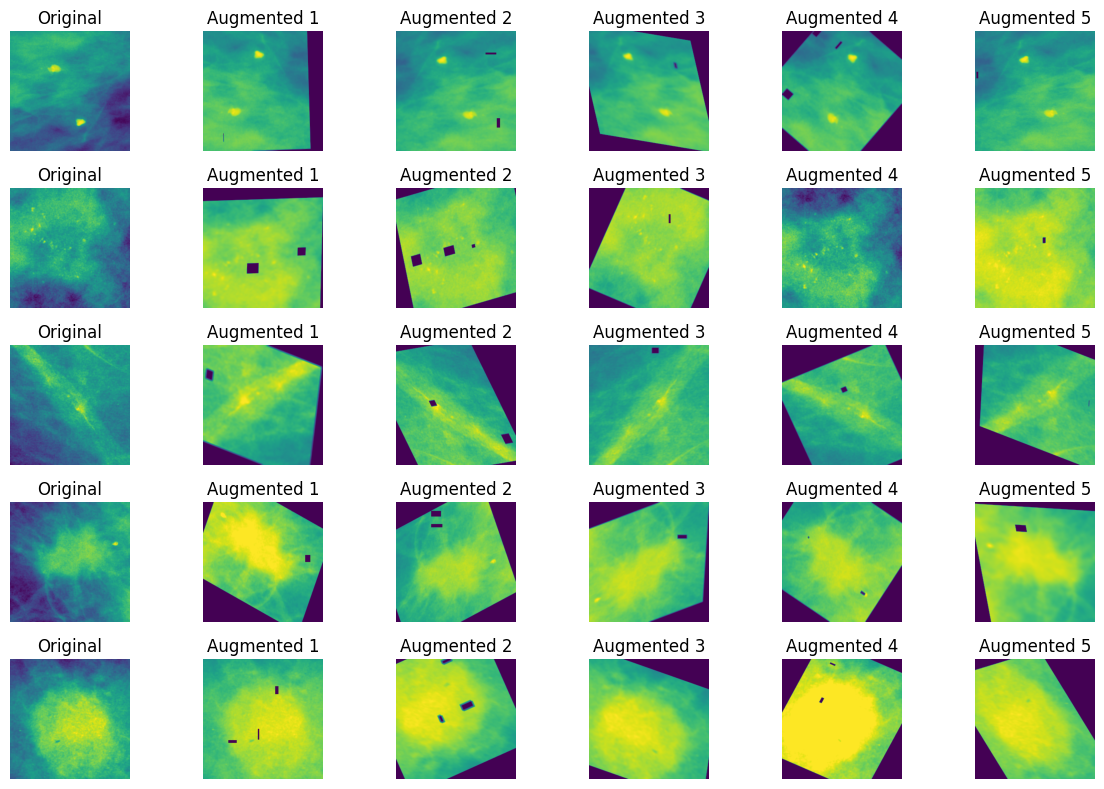

In [13]:
# Check the results of augmentation
sample_images = [np.array(Image.open(path)) for path in df_train_by_image["processed"].sample(5)]

visualize_augmentation(augment_fn, sample_images, num_examples=5)

#### Perform augmentation and save as PNGs

In [14]:
print(f"Augmenting each sample with {N_AUGMENT} additional images.")

augment_images(df_train_by_image["processed"], dir_augmented, N_AUGMENT, augment_fn)
augment_images(df_val_by_image["processed"], dir_augmented, N_AUGMENT, augment_fn)

augment_images(df_train_by_patient["processed"], dir_augmented, N_AUGMENT, augment_fn)
augment_images(df_val_by_patient["processed"], dir_augmented, N_AUGMENT, augment_fn)

Augmenting each sample with 10 additional images.


Augmenting images: 100%|██████████| 536/536 [02:01<00:00,  4.43it/s]


In [15]:
augmented_paths = [path for path in list(dir_augmented.glob("*.png"))]

df_augmented = pd.DataFrame(
    {
        "augmented": str(path),
        "augmentID": path.stem,
        "imageID": re.sub(r"-augmented-\d$", "", path.stem),
    }
    for path in augmented_paths
)
# df_augmented =

In [16]:
df_train_by_image_aug = df_train_by_image.merge(df_augmented, how="inner", on="imageID")
df_val_by_image_aug = df_val_by_image.merge(df_augmented, how="inner", on="imageID")
df_train_by_patient_aug = df_train_by_patient.merge(df_augmented, how="inner", on="imageID")
df_val_by_patient_aug = df_val_by_patient.merge(df_augmented, how="inner", on="imageID")

In [17]:
df_train_by_image_aug.to_csv(dir_data_split/"train_image_random_aug.csv")
df_val_by_image_aug.to_csv(dir_data_split/"val_image_random_aug.csv")
df_train_by_patient_aug.to_csv(dir_data_split/"train_patient_random_aug.csv")
df_val_by_patient_aug.to_csv(dir_data_split/"val_patient_random_aug.csv")

In [18]:
# for x in ["train", "val"]:
#     for y in ["image_random", "patient_random"]:
#         input_folder = dir_augmented / x / y
#         output_file = dir_data_split / f"{x}_{y}_aug.csv"
#         pd.DataFrame(
#             [{"filepath": str(path)} for path in (input_folder).glob("*/*.png")]
#         ).to_csv(output_file, index=False)

## Environment

In [43]:
!conda env export

name: data_env
channels:
  - defaults
dependencies:
  - _libgcc_mutex=0.1=main
  - _openmp_mutex=5.1=1_gnu
  - bzip2=1.0.8=h5eee18b_6
  - ca-certificates=2025.9.9=h06a4308_0
  - expat=2.7.1=h6a678d5_0
  - ld_impl_linux-64=2.40=h12ee557_0
  - libffi=3.4.4=h6a678d5_1
  - libgcc-ng=11.2.0=h1234567_1
  - libgomp=11.2.0=h1234567_1
  - libstdcxx-ng=11.2.0=h1234567_1
  - libuuid=1.41.5=h5eee18b_0
  - libxcb=1.17.0=h9b100fa_0
  - libzlib=1.3.1=hb25bd0a_0
  - ncurses=6.5=h7934f7d_0
  - openssl=3.0.17=h5eee18b_0
  - pip=25.2=pyhc872135_0
  - pthread-stubs=0.3=h0ce48e5_1
  - python=3.11.13=h1a3bd86_0
  - readline=8.3=hc2a1206_0
  - setuptools=78.1.1=py311h06a4308_0
  - sqlite=3.50.2=hb25bd0a_1
  - tk=8.6.15=h54e0aa7_0
  - wheel=0.45.1=py311h06a4308_0
  - xorg-libx11=1.8.12=h9b100fa_1
  - xorg-libxau=1.0.12=h9b100fa_0
  - xorg-libxdmcp=1.1.5=h9b100fa_0
  - xorg-xorgproto=2024.1=h5eee18b_1
  - xz=5.6.4=h5eee18b_1
  - zlib=1.3.1=hb25bd0a_0
  - pip:
      - absl-py==2.3.1
      - albucore==0.0.24
   